# It Was Fine to First Pick Green Commons, Actually

The [public draft data](https://www.17lands.com/public_datasets) for Aetherdrift dropped recently, giving us a chance to dive into the details of how people drafted and answer some pressing questions. The story of Aetherdrift so far is the dominance of the color green, and whenever there is one color dominating the performance metrics, the question arises of whether to believe those numbers, to draft middling commons in that color early, or to continue prioritizing strong rares and early picks in underperforming colors. 

A refrain I've observed throughout this format is the idea that "the data is misleading", that is, that the overall strength of green lends an amount of extra win rate to green commons that amounts to bias -- if you force your way into green before seeing premium cards, you shouldn't expect the same results as if you were to find your way in the honest way, by taking powerful cards in whatever colors appear (many of them presumably green  then collecting commons in your open lane. There's some obvious truth to this advice, but how does it stack up against the data?

We're going to test it using analysis I recently developed to empirically judge card quality metrics at their effectiveness in guiding P1P1 decisions. The way that analysis works is by ranking the cards in the opening pack of each draft, identifying the highest ranked card according to the metric, and replacing the results of that draft with the average results of a draft by the a player of similar skill who chose the identified card P1P1. For the details and results of that analysis, please see [this article](p1-strategy).

The metrics that performed best in that analysis were [DEq](https://docs.google.com/spreadsheets/d/1n1pfrb5q_2ICYk-vfF3Uwo8t61DJU-5T_DFe0dwk8DY/edit?usp=sharing), my custom card quality metric, and GIH WR, the 17Lands and community standard. For the new format, we have about two weeks of data, so I chose to focus on the viability of relying on the very first data release to draft over the remaining days in the data set. Specifically, I looked at GIH WR and DEq as they would have appeared on the third morning of the format, and simulated the effects of drafting using those rankings, unchanged, from that day through February 25 to make all P1P1 choices.

Broadly, the metrics performed essentially identically, on average yielding results about 0.25% greater than those achieved in the actual results, although we will see that they recommended very different cards in many circumstances. Because there was no gap in performance, I won't dwell on the differences between the metrics in this analysis, but instead what they have in common: an emphasis on drafting the best-performing color, green. Let's take a look at the broad results in a few tables. First, the overall win rates, then the frequencies by color.


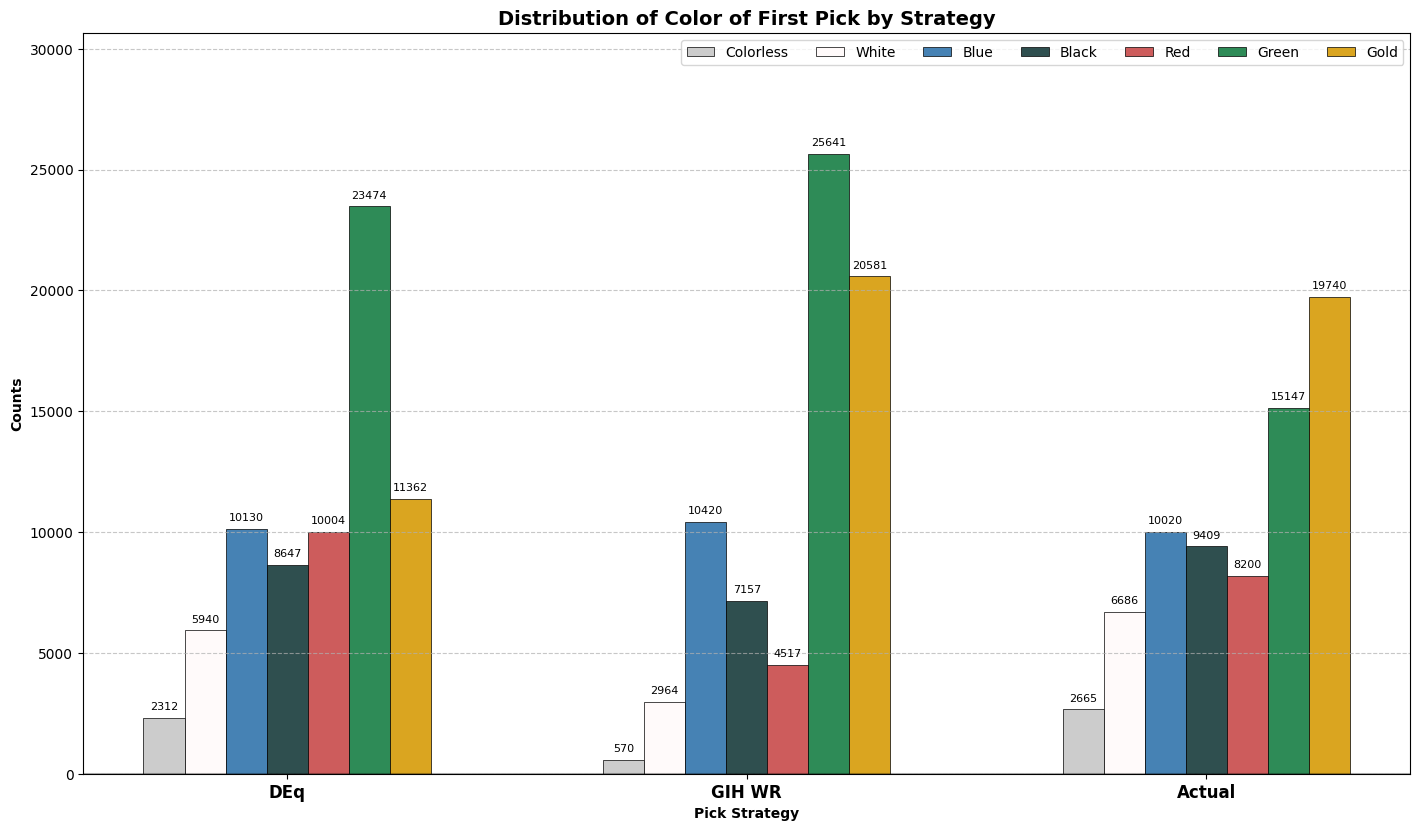

GT(_tbl_data=shape: (1, 2)
┌────────┬─────────┐
│ Drafts ┆ Matches │
│ ---    ┆ ---     │
│ i32    ┆ i64     │
╞════════╪═════════╡
│ 71868  ┆ 362457  │
└────────┴─────────┘, _body=<great_tables._gt_data.Body object at 0x7f4cac859b50>, _boxhead=Boxhead([ColInfo(var='Drafts', type=<ColInfoTypeEnum.default: 1>, column_label='Drafts', column_align='right', column_width=None), ColInfo(var='Matches', type=<ColInfoTypeEnum.default: 1>, column_label='Matches', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f4cf0683dd0>, _spanners=Spanners([]), _heading=Heading(title='Total Observations', subtitle='Days 3 Through 14', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f4ca6bc22d0>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_color=OptionsInfo(scss=True, category='heading', type='value', value=None), heading_align=OptionsInfo(scss=True, category='heading', type='value', value='center'), heading_title_font_size=OptionsInfo(scss=True, category='heading', type='px', value='125%'), heading_title_font_weight=OptionsInfo(scss=True, category='heading', type='value', value='initial'), heading_subtitle_font_size=OptionsInfo(scss=True, category='heading',

In [1]:
from deq.dft_early import *
counts_bars()
GT(count_totals).tab_header(
    title="Total Observations", subtitle="Days 3 Through 14")

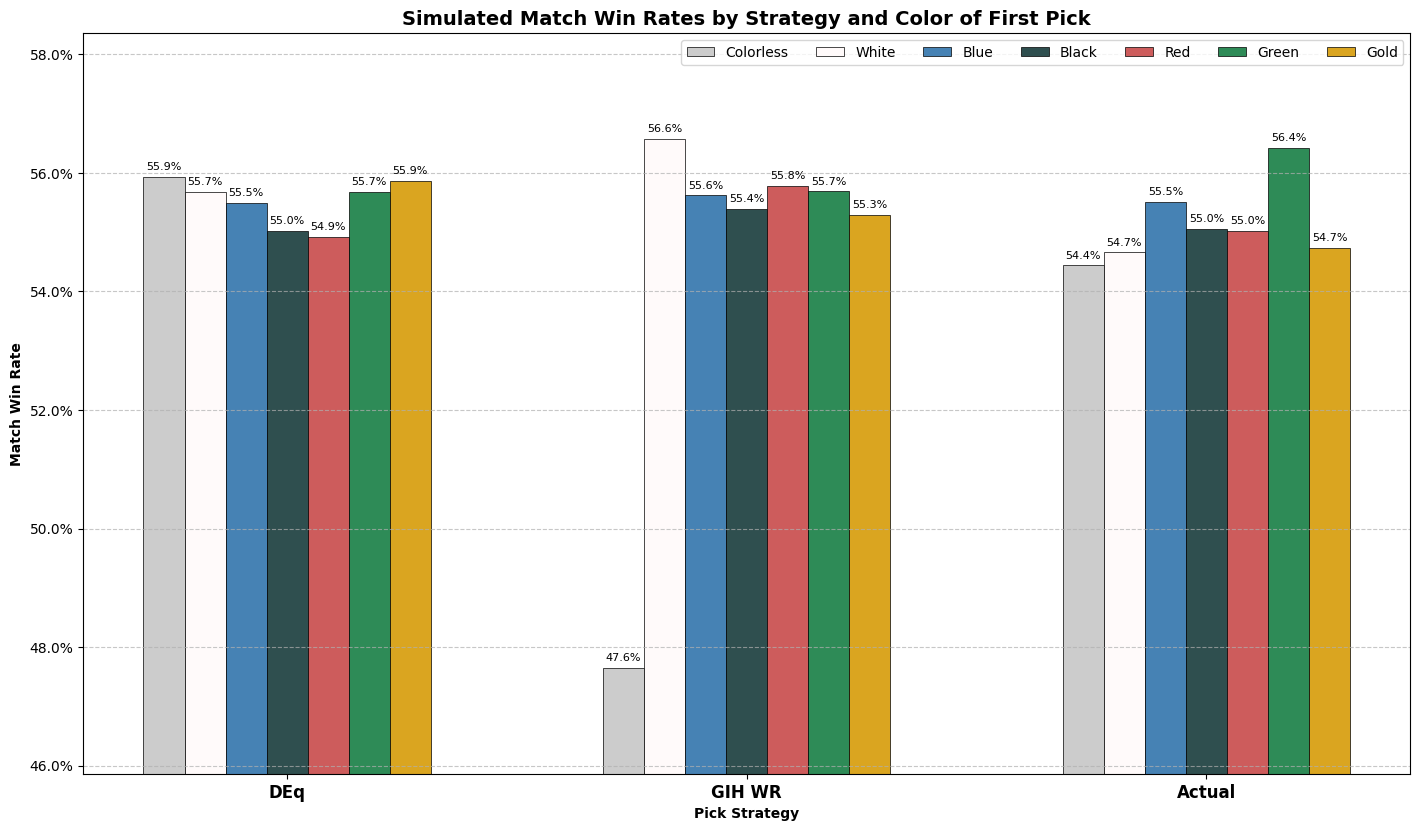

GT(_tbl_data=shape: (1, 3)
┌──────────┬──────────┬──────────┐
│ DEq      ┆ GIH WR   ┆ Actual   │
│ ---      ┆ ---      ┆ ---      │
│ f64      ┆ f64      ┆ f64      │
╞══════════╪══════════╪══════════╡
│ 0.555065 ┆ 0.555134 ┆ 0.552574 │
└──────────┴──────────┴──────────┘, _body=<great_tables._gt_data.Body object at 0x7f4ca4524310>, _boxhead=Boxhead([ColInfo(var='DEq', type=<ColInfoTypeEnum.default: 1>, column_label='DEq', column_align='right', column_width=None), ColInfo(var='GIH WR', type=<ColInfoTypeEnum.default: 1>, column_label='GIH WR', column_align='right', column_width=None), ColInfo(var='Actual', type=<ColInfoTypeEnum.default: 1>, column_label='Actual', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f4ca40133d0>, _spanners=Spanners([]), _heading=Heading(title='Simulated Match Win Rate', subtitle='by Strategy', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f4cac185790>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f4ca7d8fe10>], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_color=OptionsInfo(scss=True, category='heading', type='value', value=None), heading_align=OptionsInfo(scss=True, category='heading', type='value', value='ce

In [2]:
wr_bars()
GT(total_win_rates).fmt_percent().tab_header(title="Simulated Match Win Rate", subtitle="by Strategy")

While I'd love to dive into every nook and cranny of this analysis, we'll keep it focused on the question of green: the broad implication is that the performance metrics want you to be drafting a lot more of it. And at a glance it looks justified: in the actual results, people did much better when they started with a green card, and according to the analysis, even by lowering the quality of green first picks by taking a lot more of them, you still can be expected to end up with an above-average win rate. The 55.7% win rate simulated for GIH WR and DEq by taking green cards at the rate suggested is higher than the win rate observed in the actual results for all non-green first picks. Remember, those are results derived from observing first-picks of the specific cards identified by the day two metrics, in the specific frequencies, by players of similar skill.


**Draft the best color more often in the early format.**


You don't have to be terrified of the color drying up from one day to the next. I recall seeing chatter on day three of people being afraid of green already being cut off; twelve days later, green drafters were still having a better time of it than anyone else.

Let's dive in to the specific question of commons, because I think that's where most of the controversy is. Yes, we're going to be taking Worldwagon and presumably Autarch Mammoth first, but should we be taking Hazard of the Dunes P1P1? Rampaging Ketradon? Broken Wings? While I can't answer for sure, I think the data suggests that it was probably fine to do so for quite a few days into the early format, depending on circumstances of course. Let's break it down. First let's look at the underlying stats driving the selection process.


In [3]:
GT(common_ratings.sort("DEq", descending=True)
    ).fmt_percent(columns=['DEq'], force_sign=True
    ).fmt_percent(columns=["GIH WR"]
    ).tab_header("Day 2 Metrics", subtitle="Green Commons")

GT(_tbl_data=shape: (14, 3)
┌───────────────────────┬───────────┬──────────┐
│ Name                  ┆ DEq       ┆ GIH WR   │
│ ---                   ┆ ---       ┆ ---      │
│ str                   ┆ f64       ┆ f64      │
╞═══════════════════════╪═══════════╪══════════╡
│ Run Over              ┆ 0.034799  ┆ 0.603492 │
│ Stampeding Scurryfoot ┆ 0.026599  ┆ 0.606757 │
│ Hazard of the Dunes   ┆ 0.022063  ┆ 0.597215 │
│ Migrating Ketradon    ┆ 0.015725  ┆ 0.608167 │
│ Venomsac Lagac        ┆ 0.014635  ┆ 0.584436 │
│ …                     ┆ …         ┆ …        │
│ Broken Wings          ┆ -0.001975 ┆ 0.572229 │
│ Silken Strength       ┆ -0.004437 ┆ 0.555821 │
│ Bestow Greatness      ┆ -0.005022 ┆ 0.562472 │
│ Loxodon Surveyor      ┆ -0.006337 ┆ 0.560548 │
│ Alacrian Jaguar       ┆ -0.007658 ┆ 0.540352 │
└───────────────────────┴───────────┴──────────┘, _body=<great_tables._gt_data.Body object at 0x7f4cac8d6850>, _boxhead=Boxhead([ColInfo(var='Name', type=<ColInfoTypeEnum.default: 1>, column_label='Name', column_align='left', column_width=None), ColInfo(var='DEq', type=<ColInfoTypeEnum.default: 1>, column_label='DEq', column_align='right', column_width=None), ColInfo(var='GIH WR', type=<ColInfoTypeEnum.default: 1>, column_label='GIH WR', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f4ca557f610>, _spanners=Spanners([]), _heading=Heading(title='Day 2 Metrics', subtitle='Green Commons', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f4c9fd3fe90>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f4ca6bcdd10>, <great_tables._gt_data.FormatInfo object at 0x7f4c9fd74ed0>], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_borde

Remember, these are the day two metrics. Things changed a lot over the ensuing days, but these are the values we are stuck with for our analysis. So far I haven't emphasized the differences between DEq and GIH WR, but with some concrete examples in hand we should attempt to explain why they don't agree.

DEq estimates the value attributable to a draft pick based on where it was picked and what happened in the event overall, specifically using ATA, or average pick order, the maindeck rate, GP%, and the corresponding win rate stat GP WR. As a result, DEq boosts highly-picked and frequently-played cards quite a bit relative to GIH WR, which is one of the reasons it performs much better in matching the distribution of how top players draft.

GIH WR uses in-game data, which gives some additional signal related to card impact and effectiveness, but also introduces some biases. In particular, GIH WR is biased towards cards that fit into controlling decks, so Ketradon and Mole are boosted relative to the other green commons which are a bit more conducive to wrapping a game up. When we look at the substitution analysis, we should expect to see GIH WR drafting lots of Ketradons and DEq drafting lots of Run Overs and Scurryfoots. Let's take a look.


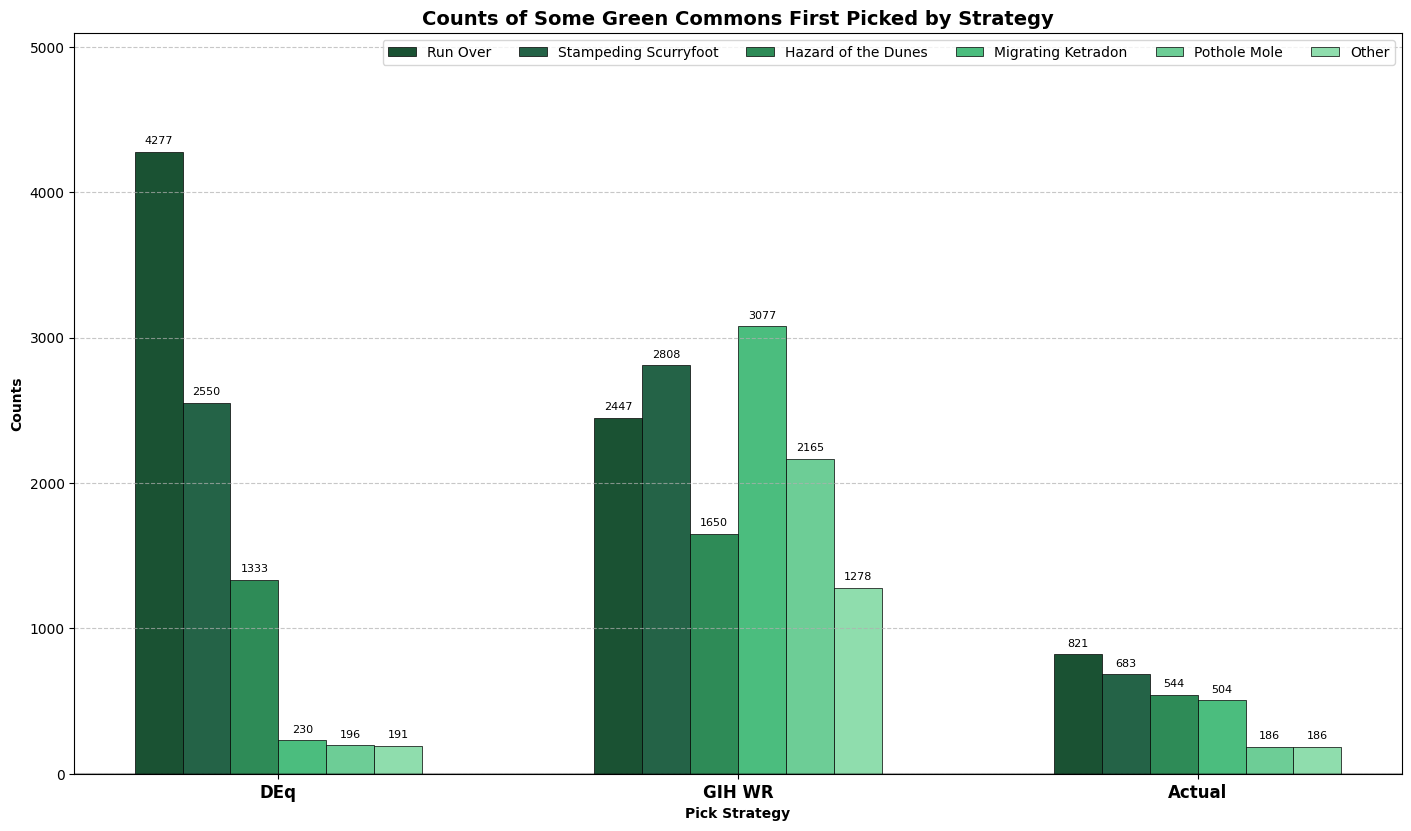

GT(_tbl_data=shape: (1, 4)
┌────────┬──────┬────────┬────────┐
│ common ┆ DEq  ┆ GIH WR ┆ Actual │
│ ---    ┆ ---  ┆ ---    ┆ ---    │
│ str    ┆ u32  ┆ u32    ┆ i32    │
╞════════╪══════╪════════╪════════╡
│ null   ┆ 8777 ┆ 13425  ┆ 2924   │
└────────┴──────┴────────┴────────┘, _body=<great_tables._gt_data.Body object at 0x7f4ca7dc4d90>, _boxhead=Boxhead([ColInfo(var='common', type=<ColInfoTypeEnum.hidden: 4>, column_label='common', column_align='left', column_width=None), ColInfo(var='DEq', type=<ColInfoTypeEnum.default: 1>, column_label='DEq', column_align='center', column_width=None), ColInfo(var='GIH WR', type=<ColInfoTypeEnum.default: 1>, column_label='GIH WR', column_align='center', column_width=None), ColInfo(var='Actual', type=<ColInfoTypeEnum.default: 1>, column_label='Actual', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f4ca7dc6a50>, _spanners=Spanners([]), _heading=Heading(title='Green Common Pick Counts', subtitle='by Strategy', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f4ca6b0ccd0>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_color=OptionsInfo(scss=True, category='heading', type='value', value=None), heading_al

In [4]:
common_counts_bar()

GT(common_counts.sum(
)).tab_header(title="Green Common Pick Counts", subtitle="by Strategy").cols_hide('common')

Hopefully this chart makes sense in light of the rankings
above. DEq is largely reflecting the shape of the actual picks due to its use of pick order data, but with an exaggerated shape since it is following a hard-and-fast rule rather than the loose preferences of actual drafters. GIH WR, on the other hand, is just going ham on every green common in sight. 13,425 is a lot of drafts! There are about 72,000 in the whole dataset, so GIH WR wanted you first-picking a green common in almost one in five drafts.


The final piece of the puzzle is the results, but I need to remind you a bit of the methodology. The results in the "simulated" strategy are derived from actual observed results when a player of similar skill took the observed card. But take a look at those actual draft counts: when we are simulating the win rate for the 2165 selections of Pothole Mole by GIH WR, we are relying on a mere 186 observations, distributed across 13 different skill cohorts. The 4277 selections of Run Over by DEq, on the other hand, are supported by the data collected in 821 actual observations.

Next, the results we are comparing to aren't going to be those actual results represented on the right. We don't want to know how people *actually* did when they took green commons, we want to know how they did *instead* of taking green commons. So for the 8777 packs where DEq wants to first-pick a green common, we will take a look at the results of those drafts (whether or not they took the card in question), and similarly for the 13,425 drafts where GIH WR wants to first-pick a green common, we will look at the actual results of those. Let's take a look.


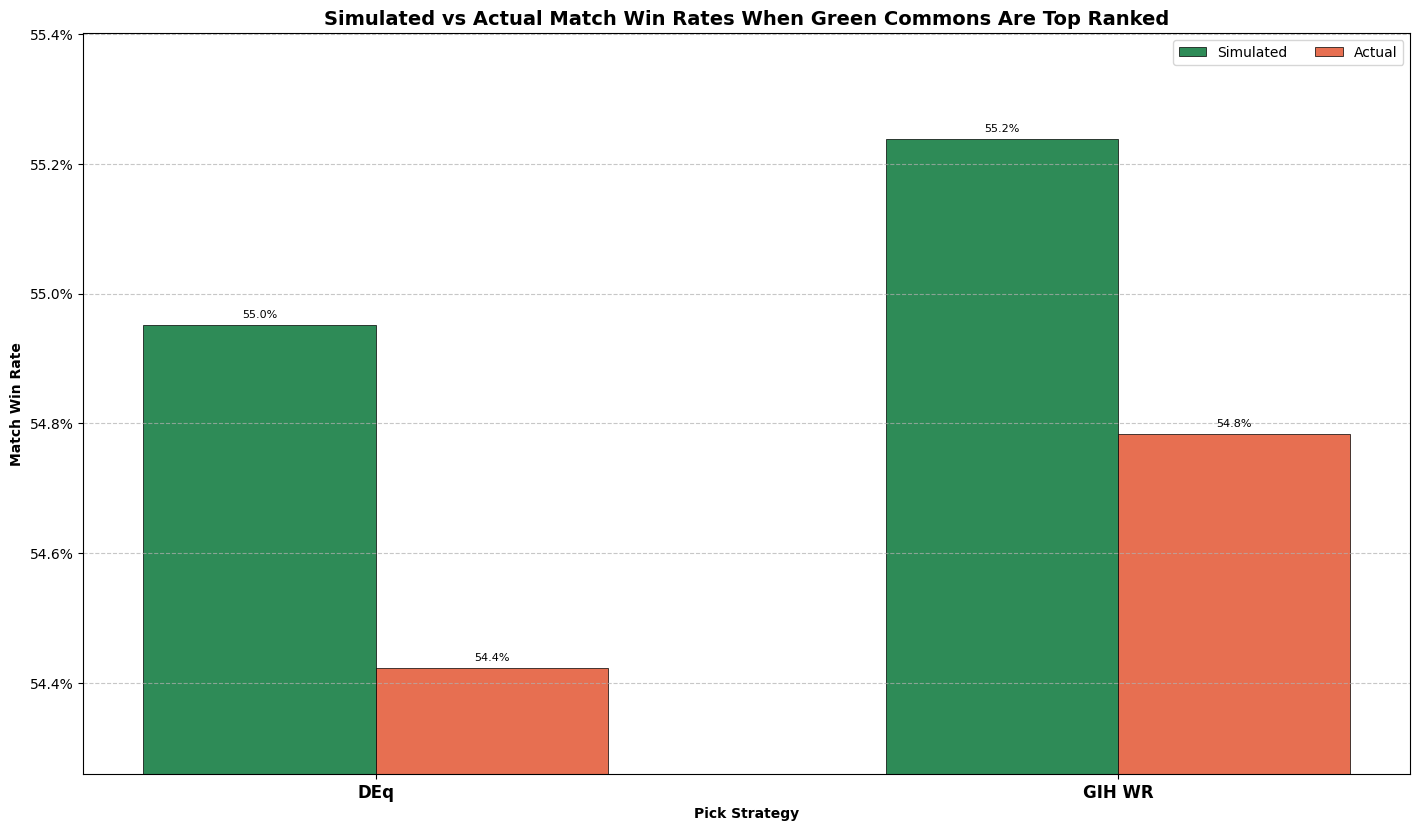

In [5]:
common_results_bar()

Both DEq and GIH WR project a boost in win rate of at least 0.4% from this slice of the strategy. So the analysis suggests a certain amount of common-grabbing was justifiable in the early format. Note that those comparison win-rates are well below the overall observed mean of 55.26%. This is because, well, as highly ranked as green commons might be, they aren't as high as Sab-Sunen or even Perilous Snare, so whatever alternatives the observed players had, they didn't include the best rares in the set. And DEq, being more selective, also narrows in on a lower-quality set of packs overall. As for how intensely you should believe this result, it's difficult for me to quantify the degree to which the result is statistically significant, given the complexity of the analysis. I certainly think examples like the Pothole Mole make the GIH WR result a bit dubious, but I think the overall picture is fairly convincing. 

**First picking green commons was fine, actually.**


Before we wrap up, let's take a quick look at how these win rates evolved over the days in our sample. Was it the case that there was a massive edge to be gained in the first few days which rapidly dried up? Generally, based on the way this analysis works, that's not likely the case. People started drafting green commons heavily *after* it became clear that green was dominant, so the samples pulled for the simulated win rate tend to come later on average than the opened packs themselves. This should actually decrease the effect relative to what could have been achieved. But let's take a quick look at the overall match win rate when first-picking the five premium green commons by day, compared to the win rate observed when the cards in question were top-ranked by DEq.



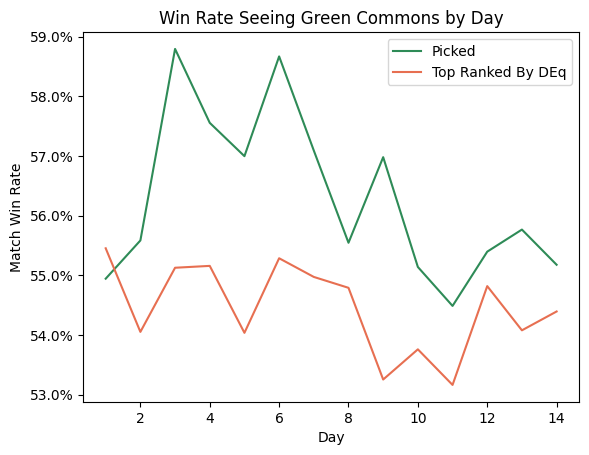

In [6]:
by_day_plot()

On one hand, the graph shows a clear decline, but on the other, we should have even more confidence that especially in those early days, when we would actually be relying on day-two metrics, first-picking premium green commons might have been even stronger than our analysis indicated. At no point is it clear that the DEq metric erred in suggesting a green common as the pick.


Well, I can't think of anything else to say on this topic, so I'll leave it at that. If you have any questions or suggestions for additional analysis, please reach out! As always, deepest thanks to the team at 17Lands for providing this data. Please support their work!

